# Arm Geometry Parameters

This notebook computes simulation parameters from physical arm segment measurements.

Core convention:
- `O_A` is the 3DOF pivot and the origin of the arm frame `A`.
- The compensator COM `C` is fixed at one tip of the arm.
- The UAV/body COM `B` is fixed at the other tip of the bent side.
- You measure only the offset from compensator tip `C` to pivot `O_A`, along the first/no-bend arm segment.
- All `A`-frame vectors exported to simulation are computed from that choice of `O_A`.

Exported symbolic-model convention:
- Geometry vectors are `[x_A, y_A, z_A]` measured from `O_A`.
- The arm lies in the `X-Z` plane, so `Y_A = 0` for all arm nodes.
- At zero attitude, gravity points along `-Z_N`; at zero pose `A` and `N` are aligned.

Important inertia convention:
- The symbolic model already includes translational kinetic energy of each component COM.
- Therefore `Ia`, `Ib`, and `Ic` exported to `geometry_param.py` should be rotational inertias about each component COM, expressed in `A` axes.
- Inertias shifted to `O_A` and total-system inertias are printed as diagnostics.


In [17]:
import warnings
import numpy as np

np.set_printoptions(precision=8, suppress=False)


## Inputs

Enter physical segment lengths and the measured pivot location. Segment lengths are not entered as arm-frame coordinates; the code below reconstructs the `A`-frame geometry.

Geometry reconstruction assumption:
1. The no-bend side starts at compensator COM `C` and runs along `+X` to the first bend.
2. The diagonal segment goes further `+X` and down in `-Z`.
3. The bottom segment goes further `+X` at constant `Z`.
4. The upright segment goes up in `+Z` to the UAV/body COM `B`.

If your physical bent side has a different topology, update only the reconstruction cell, not the mass-property cells.


In [18]:
# =========================
# 1. USER INPUTS
# =========================
# Units: meters, kilograms, kg*m^2.
mm = 1e-3

g = 9.81

# Component masses.
ma = 0.5   # arm mass
mc = 0.06   # compensator mass

# LiteWing body data.
# Source: https://circuitdigest.com/wiki/litewing/
# CircuitDigest lists LiteWing dimensions as 100 mm x 100 mm and weight as ~45 g.
litewing_frame_span = 100.0 * mm
quad_l = 0.5 * litewing_frame_span
mb = 45.0e-3   # UAV/body mass without battery

# Optional battery mass if you later want to include it explicitly in the body mass.
litewing_battery_mass = 0.0
mb = mb + litewing_battery_mass

# Physical arm segment lengths.
# C -- straight/no-bend --> bend -- diagonal --> lower bend -- bottom --> upright -- B
L_C_to_bend = 300.0 * mm
L_diagonal  = 172.75416 * mm
L_bottom    = 60.0 * mm
L_upright   = 162.0 * mm

# Measured pivot location: distance from compensator COM/tip C to O_A along the no-bend segment.
# Valid design range for O_A on the no-bend segment: 0 <= C_to_OA <= L_C_to_bend.
C_to_OA = 260.0 * mm

# Very small physical radius of the arm segments for solid slender-rod inertia.
# Set to 0.0 for ideal line-segment inertia.
arm_radius = 1.0 * mm

# The current symbolic model accepts body/compensator inertia as diagonal entries only.
# Compensator inertia is still user-specified directly.
Ic_com = np.diag([0.030, 0.025, 0.020])



## Geometry Reconstruction

This cell converts segment lengths into `A`-frame node coordinates. The pivot `O_A` is not calculated; it is the origin by definition. Changing `C_to_OA` moves the origin along the physical no-bend segment, and all positions are recomputed relative to it.


In [19]:
# =========================
# 2. RECONSTRUCT ARM GEOMETRY FROM SEGMENT LENGTHS
# =========================
if C_to_OA < 0.0:
    warnings.warn("C_to_OA is negative. O_A is before the compensator tip, outside the physical arm.")
if C_to_OA > L_C_to_bend:
    warnings.warn(
        "C_to_OA is beyond the first bend. O_A is no longer on the no-bend side of the arm."
    )

if L_diagonal < L_upright:
    raise ValueError("L_diagonal must be at least L_upright for this reconstruction assumption.")

# Build geometry in a C-tip reference frame first. C is at [0,0,0].
# The diagonal horizontal run follows from the measured diagonal and upright lengths.
diagonal_x_run = float(np.sqrt(max(L_diagonal**2 - L_upright**2, 0.0)))

pC_ref = np.array([0.0, 0.0, 0.0])
p_bend_ref = np.array([L_C_to_bend, 0.0, 0.0])
p_lower_ref = p_bend_ref + np.array([diagonal_x_run, 0.0, -L_upright])
p_bottom_ref = p_lower_ref + np.array([L_bottom, 0.0, 0.0])
pB_ref = p_bottom_ref + np.array([0.0, 0.0, L_upright])

arm_nodes_ref = np.vstack([pC_ref, p_bend_ref, p_lower_ref, p_bottom_ref, pB_ref])

# Shift into A-frame: O_A is the origin and lies C_to_OA from C along +X.
pOA_ref = np.array([C_to_OA, 0.0, 0.0])
arm_nodes_A = arm_nodes_ref - pOA_ref

# Component COM positions from O_A in A-frame.
rC_A = pC_ref - pOA_ref
rB_A = pB_ref - pOA_ref

# This is intentionally zero by definition: O_A is the pivot and A-frame origin.
OA_A = np.zeros(3)


## Mass-Property Helpers

The arm is modeled as homogeneous with linear density along the measured segments. Each segment is treated as a solid slender cylinder with a very small radius.


In [20]:
# =========================
# 3. MASS PROPERTY HELPERS
# =========================
def parallel_axis_matrix(r):
    """Return (r.r I - r r^T), used in the parallel-axis theorem."""
    r = np.asarray(r, dtype=float).reshape(3)
    return np.dot(r, r) * np.eye(3) - np.outer(r, r)


def shift_inertia_from_com_to_origin(I_com, mass, r_com_from_origin):
    """Shift inertia from a component COM to the selected origin."""
    return np.asarray(I_com, dtype=float) + mass * parallel_axis_matrix(r_com_from_origin)


def shift_inertia_from_origin_to_com(I_origin, mass, r_com_from_origin):
    """Shift inertia from an origin back to the component COM."""
    return np.asarray(I_origin, dtype=float) - mass * parallel_axis_matrix(r_com_from_origin)


def solid_slender_segment_inertia_com(mass, length, radius, direction):
    """Solid-cylinder inertia about segment COM, expressed in global A axes."""
    direction = np.asarray(direction, dtype=float).reshape(3)
    direction = direction / np.linalg.norm(direction)

    I_along = 0.5 * mass * radius**2
    I_trans = (mass / 12.0) * (3.0 * radius**2 + length**2)

    I3 = np.eye(3)
    uu = np.outer(direction, direction)
    return I_along * uu + I_trans * (I3 - uu)


def polyline_mass_properties(nodes_A, total_mass, radius=0.0):
    """Homogeneous solid-slender-rod mass properties for a connected 3D polyline."""
    nodes_A = np.asarray(nodes_A, dtype=float)
    if nodes_A.ndim != 2 or nodes_A.shape[1] != 3 or len(nodes_A) < 2:
        raise ValueError("arm_nodes_A must have shape (N, 3), with N >= 2.")

    segments = nodes_A[1:] - nodes_A[:-1]
    segment_lengths = np.linalg.norm(segments, axis=1)
    total_length = float(np.sum(segment_lengths))
    if total_length <= 0.0:
        raise ValueError("Arm polyline total length must be positive.")

    I_about_OA = np.zeros((3, 3))
    com = np.zeros(3)
    segment_masses = total_mass * segment_lengths / total_length

    for a, b, length, mass_i in zip(nodes_A[:-1], nodes_A[1:], segment_lengths, segment_masses):
        if length <= 1e-12:
            continue

        direction = (b - a) / length
        com_i = 0.5 * (a + b)
        I_segment_com = solid_slender_segment_inertia_com(mass_i, length, radius, direction)
        I_about_OA += shift_inertia_from_com_to_origin(I_segment_com, mass_i, com_i)
        com += mass_i * com_i

    com /= total_mass
    I_about_com = shift_inertia_from_origin_to_com(I_about_OA, total_mass, com)
    return com, I_about_com, I_about_OA, segment_lengths, segment_masses


def quad_point_mass_inertia_about_com(total_mass, arm_length):
    """Simple '+'-layout quad inertia from four equal rotor masses at distance arm_length."""
    rotor_mass = float(total_mass) / 4.0
    l = float(arm_length)
    rotor_positions = np.array([
        [0.0, +l, 0.0],
        [+l, 0.0, 0.0],
        [0.0, -l, 0.0],
        [-l, 0.0, 0.0],
    ])

    inertia = np.zeros((3, 3))
    for rotor_pos in rotor_positions:
        inertia += rotor_mass * parallel_axis_matrix(rotor_pos)

    return np.diag(np.diag(inertia))



## Compute Parameters

This computes arm COM from the homogeneous polyline, total COM from all three masses, and the parameter dictionary expected by the simulation model.


In [21]:
# =========================
# 4. COMPUTE COMPONENT AND TOTAL PROPERTIES
# =========================
rO_A, Ia_com, Ia_OA, segment_lengths, segment_masses = polyline_mass_properties(
    arm_nodes_A,
    ma,
    radius=arm_radius,
)

Ib_com = quad_point_mass_inertia_about_com(mb, quad_l)
Ib_OA = shift_inertia_from_com_to_origin(Ib_com, mb, rB_A)
Ic_OA = shift_inertia_from_com_to_origin(Ic_com, mc, rC_A)

m_total = ma + mb + mc
rG_A = (ma * rO_A + mb * rB_A + mc * rC_A) / m_total
I_total_OA = Ia_OA + Ib_OA + Ic_OA
I_total_G = shift_inertia_from_origin_to_com(I_total_OA, m_total, rG_A)

# Parameters consumed by the exported symbolic equations.
params = {
    'g': g,
    'ma': ma,
    'mb': mb,
    'mc': mc,
    'Iaxx': float(Ia_com[0, 0]),
    'Iayy': float(Ia_com[1, 1]),
    'Iazz': float(Ia_com[2, 2]),
    'Iaxy': float(Ia_com[0, 1]),
    'Iaxz': float(Ia_com[0, 2]),
    'Iayz': float(Ia_com[1, 2]),
    'Ibx': float(Ib_com[0, 0]),
    'Iby': float(Ib_com[1, 1]),
    'Ibz': float(Ib_com[2, 2]),
    'Icx': float(Ic_com[0, 0]),
    'Icy': float(Ic_com[1, 1]),
    'Icz': float(Ic_com[2, 2]),
    'xO_A': float(rO_A[0]),
    'yO_A': float(rO_A[1]),
    'zO_A': float(rO_A[2]),
    'xB_A': float(rB_A[0]),
    'yB_A': float(rB_A[1]),
    'zB_A': float(rB_A[2]),
    'xC_A': float(rC_A[0]),
    'yC_A': float(rC_A[1]),
    'zC_A': float(rC_A[2]),
}

quad_params = {
    'model_name': 'LiteWing',
    'spec_source_url': 'https://circuitdigest.com/wiki/litewing/',
    'frame_span_m': float(litewing_frame_span),
    'quad_l': float(quad_l),
}



## Sanity Check 0: Pivot Origin Convention

`O_A` is the pivot point and the origin of arm frame `A`. It is not calculated from geometry. All exported geometry vectors are measured from this origin.


In [22]:
# =========================
# SANITY CHECK 0: PIVOT ORIGIN CONVENTION
# =========================
print("O_A in A-frame [m]:", OA_A)
print("Measured C -> O_A distance [m]:", C_to_OA)
print("Computed rC_A from O_A to C [m]:", rC_A)

assert np.allclose(OA_A, np.zeros(3)), "O_A must be the origin of A-frame."
assert np.isclose(np.linalg.norm(rC_A), abs(C_to_OA)), "rC_A magnitude should match measured C_to_OA."

print("PASS: O_A is fixed at the A-frame origin and rC_A is computed from measured C_to_OA.")


O_A in A-frame [m]: [0. 0. 0.]
Measured C -> O_A distance [m]: 0.26
Computed rC_A from O_A to C [m]: [-0.26  0.    0.  ]
PASS: O_A is fixed at the A-frame origin and rC_A is computed from measured C_to_OA.


## Sanity Check 1: Pivot Must Stay On No-Bend Side

The requested slider variable is `C_to_OA`. The valid physical range for placing `O_A` on the no-bend side is from the compensator tip to the first bend.


In [23]:
# =========================
# SANITY CHECK 1: O_A LOCATION ALONG NO-BEND SIDE
# =========================
print("Valid C_to_OA range [m]:", (0.0, L_C_to_bend))
print("Current C_to_OA [m]:", C_to_OA)
print("Distance from O_A to first bend [m]:", L_C_to_bend - C_to_OA)

if C_to_OA > L_C_to_bend:
    print("WARNING: O_A is beyond the first bend. Move it back toward the compensator side.")
elif C_to_OA < 0.0:
    print("WARNING: O_A is before the compensator tip. Move it onto the physical arm.")
else:
    print("PASS: O_A lies on the no-bend side before the first bend.")


Valid C_to_OA range [m]: (0.0, 0.3)
Current C_to_OA [m]: 0.26
Distance from O_A to first bend [m]: 0.03999999999999998
PASS: O_A lies on the no-bend side before the first bend.


## Sanity Check 2: Segment Length Reconstruction

This verifies that the reconstructed `A`-frame polyline preserves the measured physical segment lengths.


In [24]:
# =========================
# SANITY CHECK 2: SEGMENT LENGTH RECONSTRUCTION
# =========================
measured_lengths = np.array([L_C_to_bend, L_diagonal, L_bottom, L_upright], dtype=float)
length_error = segment_lengths - measured_lengths

print("Measured segment lengths [m]:", measured_lengths)
print("Reconstructed segment lengths [m]:", segment_lengths)
print("Segment length errors [m]:", length_error)

assert np.allclose(segment_lengths, measured_lengths, atol=1e-10), "Reconstructed segment lengths do not match inputs."

print("PASS: reconstructed geometry preserves measured segment lengths.")


Measured segment lengths [m]: [0.3        0.17275416 0.06       0.162     ]
Reconstructed segment lengths [m]: [0.3        0.17275416 0.06       0.162     ]
Segment length errors [m]: [0. 0. 0. 0.]
PASS: reconstructed geometry preserves measured segment lengths.


## Sanity Check 3: Arm Lies In The `X-Z` Plane

The physical sketch is represented in the arm-frame `X-Z` plane, with `Y_A` out of the page/screen.


In [25]:
# =========================
# SANITY CHECK 3: X-Z PLANE GEOMETRY
# =========================
tol = 1e-12
arm_y_max = float(np.max(np.abs(arm_nodes_A[:, 1])))
point_y_max = float(max(abs(rO_A[1]), abs(rB_A[1]), abs(rC_A[1]), abs(rG_A[1])))

print("Max |Y_A| over arm nodes:", arm_y_max)
print("Max |Y_A| over component and total COMs:", point_y_max)

assert arm_y_max < tol, "Arm nodes are not all in the X-Z plane. Check Y_A coordinates."
assert point_y_max < tol, "At least one COM is out of the X-Z plane."

print("PASS: arm geometry and COMs lie in the A-frame X-Z plane.")


Max |Y_A| over arm nodes: 0.0
Max |Y_A| over component and total COMs: 0.0
PASS: arm geometry and COMs lie in the A-frame X-Z plane.


## Sanity Check 4: Arm And Total COM Locations

The arm COM is calculated from the homogeneous segmented arm. The total COM is calculated from the arm, body, and compensator masses.


In [26]:
# =========================
# SANITY CHECK 4: ARM COM AND TOTAL COM FROM O_A
# =========================
print("Arm COM rO_A [m]:", rO_A)
print("Distance |rO_A| from O_A [m]:", float(np.linalg.norm(rO_A)))
print("Distance |rO_A| from O_A [mm]:", 1e3 * float(np.linalg.norm(rO_A)))

print("Total COM rG_A [m]:", rG_A)
print("Distance |rG_A| from O_A [m]:", float(np.linalg.norm(rG_A)))
print("Distance |rG_A| from O_A [mm]:", 1e3 * float(np.linalg.norm(rG_A)))

assert np.all(np.isfinite(rO_A)), "Arm COM contains non-finite values."
assert np.all(np.isfinite(rG_A)), "Total COM contains non-finite values."

print("PASS: arm COM and total COM are finite and measured from O_A.")


Arm COM rO_A [m]: [ 0.01844219  0.         -0.05301888]
Distance |rO_A| from O_A [m]: 0.05613480262599856
Distance |rO_A| from O_A [mm]: 56.13480262599856
Total COM rG_A [m]: [ 0.00135718  0.         -0.04381726]
Distance |rG_A| from O_A [m]: 0.04383826913720456
Distance |rG_A| from O_A [mm]: 43.83826913720456
PASS: arm COM and total COM are finite and measured from O_A.


## Sanity Check 5: Inertia Matrix Symmetry And Positive Semidefiniteness

Rigid-body inertia matrices must be symmetric and positive semidefinite. The shifted diagnostic inertias should preserve those properties up to numerical roundoff.


In [27]:
# =========================
# SANITY CHECK 5: INERTIA MATRICES
# =========================
def check_inertia_matrix(name, I, tolerance=1e-10):
    I = np.asarray(I, dtype=float)
    symmetry_error = float(np.max(np.abs(I - I.T)))
    eigvals = np.linalg.eigvalsh(0.5 * (I + I.T))

    print(f"{name} symmetry error:", symmetry_error)
    print(f"{name} eigenvalues:", eigvals)

    assert symmetry_error < tolerance, f"{name} is not symmetric."
    assert np.min(eigvals) > -tolerance, f"{name} is not positive semidefinite."

for name, inertia in [
    ("Ia_com", Ia_com),
    ("Ia_OA", Ia_OA),
    ("Ib_com", Ib_com),
    ("Ib_OA", Ib_OA),
    ("Ic_com", Ic_com),
    ("Ic_OA", Ic_OA),
    ("I_total_OA", I_total_OA),
    ("I_total_G", I_total_G),
]:
    check_inertia_matrix(name, inertia)

print("PASS: inertia matrices are symmetric and positive semidefinite.")


Ia_com symmetry error: 0.0
Ia_com eigenvalues: [0.00084809 0.00942307 0.01027091]
Ia_OA symmetry error: 0.0
Ia_OA eigenvalues: [0.00172784 0.01011887 0.01184647]
Ib_com symmetry error: 0.0
Ib_com eigenvalues: [5.625e-05 5.625e-05 1.125e-04]
Ib_OA symmetry error: 0.0
Ib_OA eigenvalues: [5.62500000e-05 1.20824998e-03 1.26449998e-03]
Ic_com symmetry error: 0.0
Ic_com eigenvalues: [0.02  0.025 0.03 ]
Ic_OA symmetry error: 0.0
Ic_OA eigenvalues: [0.024056 0.029056 0.03    ]
I_total_OA symmetry error: 0.0
I_total_OA eigenvalues: [0.03037044 0.03685303 0.04211072]
I_total_G symmetry error: 0.0
I_total_G eigenvalues: [0.02971726 0.03634352 0.04094803]
PASS: inertia matrices are symmetric and positive semidefinite.


## Sanity Check 6: Parallel-Axis Consistency

This checks that the diagnostic shifted inertias are consistent with the COM inertias and COM locations used in the exported parameter block.


In [28]:
# =========================
# SANITY CHECK 6: PARALLEL-AXIS CONSISTENCY
# =========================
Ia_shift_check = shift_inertia_from_com_to_origin(Ia_com, ma, rO_A)
Ib_shift_check = shift_inertia_from_com_to_origin(Ib_com, mb, rB_A)
Ic_shift_check = shift_inertia_from_com_to_origin(Ic_com, mc, rC_A)
I_total_check = Ia_shift_check + Ib_shift_check + Ic_shift_check

print("Max |Ia_OA - shifted Ia_com|:", np.max(np.abs(Ia_OA - Ia_shift_check)))
print("Max |Ib_OA - shifted Ib_com|:", np.max(np.abs(Ib_OA - Ib_shift_check)))
print("Max |Ic_OA - shifted Ic_com|:", np.max(np.abs(Ic_OA - Ic_shift_check)))
print("Max |I_total_OA - sum shifted components|:", np.max(np.abs(I_total_OA - I_total_check)))

assert np.allclose(Ia_OA, Ia_shift_check)
assert np.allclose(Ib_OA, Ib_shift_check)
assert np.allclose(Ic_OA, Ic_shift_check)
assert np.allclose(I_total_OA, I_total_check)

print("PASS: shifted diagnostic inertias are parallel-axis consistent.")


Max |Ia_OA - shifted Ia_com|: 0.0
Max |Ib_OA - shifted Ib_com|: 0.0
Max |Ic_OA - shifted Ic_com|: 0.0
Max |I_total_OA - sum shifted components|: 0.0
PASS: shifted diagnostic inertias are parallel-axis consistent.


## Sanity Check 7: Exported Parameter Set

The simulation loader expects this exact parameter set and order. This check catches missing or accidental extra keys before copying into `geometry_param.py`.


In [29]:
# =========================
# SANITY CHECK 7: PARAMETER KEYS
# =========================
expected_keys = [
    'g', 'ma', 'mb', 'mc',
    'Iaxx', 'Iayy', 'Iazz', 'Iaxy', 'Iaxz', 'Iayz',
    'Ibx', 'Iby', 'Ibz', 'Icx', 'Icy', 'Icz',
    'xO_A', 'yO_A', 'zO_A',
    'xB_A', 'yB_A', 'zB_A',
    'xC_A', 'yC_A', 'zC_A',
]

missing = [key for key in expected_keys if key not in params]
extra = [key for key in params if key not in expected_keys]

print("Missing keys:", missing)
print("Extra keys:", extra)

assert not missing, "Missing simulation parameters."
assert not extra, "Unexpected parameters in export block."

print("PASS: exported parameter set matches the simulation model.")


Missing keys: []
Extra keys: []
PASS: exported parameter set matches the simulation model.


## Sanity Check 8: Visual X-Z Geometry Check

This true-scale plot shows the reconstructed arm geometry in the `A`-frame `X-Z` plane. The horizontal axis is `X_A`, the vertical axis is `Z_A`, and the aspect ratio is locked to 1:1 so distances are not visually distorted.


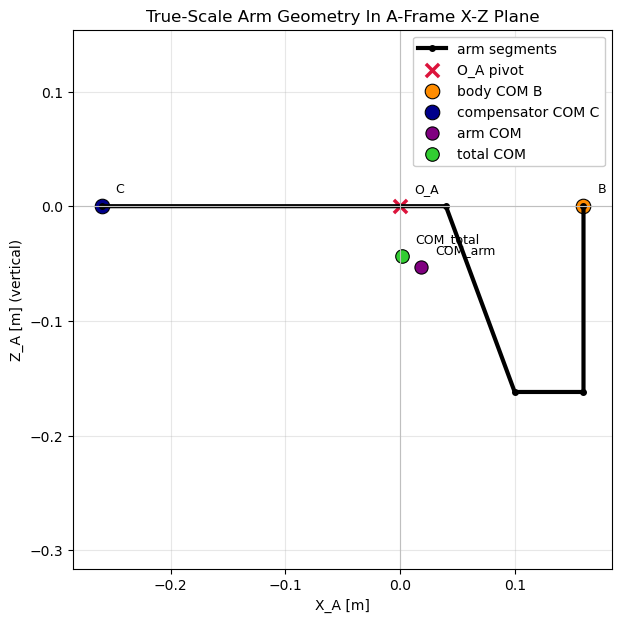

In [30]:
# =========================
# SANITY CHECK 8: TRUE-SCALE X-Z GEOMETRY PLOT
# =========================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.0, 7.0))

# Arm centerline.
ax.plot(
    arm_nodes_A[:, 0],
    arm_nodes_A[:, 2],
    color="black",
    linewidth=3.0,
    marker="o",
    markersize=4.0,
    label="arm segments",
)

# Pivot and attached masses.
ax.scatter(OA_A[0], OA_A[2], s=90, color="crimson", marker="x", linewidths=2.5, label="O_A pivot")
ax.scatter(rB_A[0], rB_A[2], s=110, color="darkorange", edgecolor="black", linewidth=0.8, label="body COM B")
ax.scatter(rC_A[0], rC_A[2], s=110, color="darkblue", edgecolor="black", linewidth=0.8, label="compensator COM C")

# Computed COMs.
ax.scatter(rO_A[0], rO_A[2], s=90, color="purple", edgecolor="black", linewidth=0.8, label="arm COM")
ax.scatter(rG_A[0], rG_A[2], s=95, color="limegreen", edgecolor="black", linewidth=0.8, label="total COM")

# Light annotation, offset in data units for readability.
label_offset = 0.012
labels = [
    ("O_A", OA_A),
    ("B", rB_A),
    ("C", rC_A),
    ("COM_arm", rO_A),
    ("COM_total", rG_A),
]
for text, point in labels:
    ax.text(point[0] + label_offset, point[2] + label_offset, text, fontsize=9)

# Keep true geometry dimensions: equal scale on X and Z.
all_x = np.concatenate([arm_nodes_A[:, 0], [OA_A[0], rB_A[0], rC_A[0], rO_A[0], rG_A[0]]])
all_z = np.concatenate([arm_nodes_A[:, 2], [OA_A[2], rB_A[2], rC_A[2], rO_A[2], rG_A[2]]])
x_mid = 0.5 * (float(np.min(all_x)) + float(np.max(all_x)))
z_mid = 0.5 * (float(np.min(all_z)) + float(np.max(all_z)))
span = max(float(np.max(all_x) - np.min(all_x)), float(np.max(all_z) - np.min(all_z)))
padding = max(0.05 * span, 0.025)
half_range = 0.5 * span + padding

ax.set_xlim(x_mid - half_range, x_mid + half_range)
ax.set_ylim(z_mid - half_range, z_mid + half_range)
ax.set_aspect("equal", adjustable="box")

ax.axhline(0.0, color="0.75", linewidth=0.8)
ax.axvline(0.0, color="0.75", linewidth=0.8)
ax.grid(True, alpha=0.3)
ax.set_xlabel("X_A [m]")
ax.set_ylabel("Z_A [m] (vertical)")
ax.set_title("True-Scale Arm Geometry In A-Frame X-Z Plane")
ax.legend(loc="best", framealpha=1.0)

plt.show()


## Review Results

Use this section to inspect the geometry and mass properties before copying parameters into `geometry_param.py`.


In [31]:
# =========================
# 5. REVIEW RESULTS
# =========================
print("Arm nodes in A-frame [m]:")
print(arm_nodes_A)
print("\nSegment masses [kg]:")
print(segment_masses)
print("\nArm segment lengths [m]:")
print(segment_lengths)

print("\nLiteWing frame span [m]:", litewing_frame_span)
print("LiteWing quad arm length quad_l [m]:", quad_l)
print("LiteWing body mass mb [kg]:", mb)

print("\nBody COM rB_A [m]:")
print(rB_A)
print("Compensator COM rC_A [m]:")
print(rC_A)
print("Arm COM rO_A [m]:")
print(rO_A)
print("Total COM rG_A [m]:")
print(rG_A)

print("\nArm inertia about arm COM [kg*m^2] - used for Ia params:")
print(Ia_com)
print("Arm inertia shifted to O_A [kg*m^2] - diagnostic only:")
print(Ia_OA)

print("\nBody inertia about body COM [kg*m^2] - used for Ib params:")
print(Ib_com)
print("Body inertia shifted to O_A [kg*m^2] - diagnostic only:")
print(Ib_OA)

print("\nCompensator inertia about compensator COM [kg*m^2] - used for Ic params:")
print(Ic_com)
print("Compensator inertia shifted to O_A [kg*m^2] - diagnostic only:")
print(Ic_OA)

print("\nTotal mass [kg]:", m_total)
print("Total inertia about O_A [kg*m^2] - diagnostic only:")
print(I_total_OA)
print("Total inertia about total COM [kg*m^2] - diagnostic only:")
print(I_total_G)



Arm nodes in A-frame [m]:
[[-0.26   0.     0.   ]
 [ 0.04   0.     0.   ]
 [ 0.1    0.    -0.162]
 [ 0.16   0.    -0.162]
 [ 0.16   0.     0.   ]]

Segment masses [kg]:
[0.21590371 0.12432755 0.04318074 0.116588  ]

Arm segment lengths [m]:
[0.3        0.17275416 0.06       0.162     ]

LiteWing frame span [m]: 0.1
LiteWing quad arm length quad_l [m]: 0.05
LiteWing body mass mb [kg]: 0.045

Body COM rB_A [m]:
[0.16 0.   0.  ]
Compensator COM rC_A [m]:
[-0.26  0.    0.  ]
Arm COM rO_A [m]:
[ 0.01844219  0.         -0.05301888]
Total COM rG_A [m]:
[ 0.00135718  0.         -0.04381726]

Arm inertia about arm COM [kg*m^2] - used for Ia params:
[[0.00183546 0.         0.00273711]
 [0.         0.01027091 0.        ]
 [0.00273711 0.         0.0084357 ]]
Arm inertia shifted to O_A [kg*m^2] - diagnostic only:
[[0.00324096 0.         0.003226  ]
 [0.         0.01184647 0.        ]
 [0.003226   0.         0.00860576]]

Body inertia about body COM [kg*m^2] - used for Ib params:
[[5.625e-05 0.000e+

## Copy-Ready `geometry_param.py` Block

Copy the printed function body into `geometry_param.py` for simulations.


In [32]:
# =========================
# 6. COPY-READY geometry_param.py CONTENT
# =========================
def format_float(x):
    return f"{float(x):.12g}"

ordered_keys = [
    'g', 'ma', 'mb', 'mc',
    'Iaxx', 'Iayy', 'Iazz', 'Iaxy', 'Iaxz', 'Iayz',
    'Ibx', 'Iby', 'Ibz', 'Icx', 'Icy', 'Icz',
    'xO_A', 'yO_A', 'zO_A',
    'xB_A', 'yB_A', 'zB_A',
    'xC_A', 'yC_A', 'zC_A',
]

print("def get_quad_params():")
print("    return {")
for key in ['model_name', 'spec_source_url', 'frame_span_m', 'quad_l']:
    value = quad_params[key]
    if isinstance(value, str):
        print(f"        '{key}': '{value}',")
    else:
        print(f"        '{key}': {format_float(value)},")
print("    }")
print()
print("def get_params():")
print("    return {")
for key in ordered_keys:
    print(f"        '{key}': {format_float(params[key])},")
print("    }")



def get_quad_params():
    return {
        'model_name': 'LiteWing',
        'spec_source_url': 'https://circuitdigest.com/wiki/litewing/',
        'frame_span_m': 0.1,
        'quad_l': 0.05,
    }

def get_params():
    return {
        'g': 9.81,
        'ma': 0.5,
        'mb': 0.045,
        'mc': 0.06,
        'Iaxx': 0.00183545735083,
        'Iayy': 0.0102709090504,
        'Iazz': 0.00843570169962,
        'Iaxy': 0,
        'Iaxz': 0.0027371070607,
        'Iayz': 0,
        'Ibx': 5.625e-05,
        'Iby': 5.625e-05,
        'Ibz': 0.0001125,
        'Icx': 0.03,
        'Icy': 0.025,
        'Icz': 0.02,
        'xO_A': 0.0184421935367,
        'yO_A': 0,
        'zO_A': -0.0530188793112,
        'xB_A': 0.159999998311,
        'yB_A': 0,
        'zB_A': 0,
        'xC_A': -0.26,
        'yC_A': 0,
        'zC_A': 0,
    }
